##### This script contains the following:

#### 1. Importing libraries and datasets
#### 2. Data Wrangling
#### 3. Reshaping
#### 4. Data Split
#### 5. Optimizing Hyperparameters
#### 6. Creating Random Forest with Optimized Hyperparameters
#### 7. Feature Importances

### 1. Importing libraries and datasets

In [5]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [7]:
# Defining a path for importing/exporting
path = r'/Users/peterguan/ClimateWins ML'

In [9]:
# Importing the Cleaned Weather Observations dataset
climatewins_cleaned = pd.read_csv(r'/Users/peterguan/ClimateWins ML/Data Sets/climatewins_clean_weather_observations.csv', index_col = False)

In [11]:
# Checking if the dataset was imported successfully 
climatewins_cleaned.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [13]:
# Checking the dimensions
climatewins_cleaned.shape

(22950, 137)

In [15]:
# Importing the PLEASANT WEATHER dataset
pleasantweather = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [17]:
# Checking if the dataset was imported successfully 
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
# Checking the dimensions
pleasantweather.shape

(22950, 16)

### 2. Data Wrangling

In [24]:
# Create a list of the columns containing "Kassel" in their names

Kassel_list = list(climatewins_cleaned for climatewins_cleaned in climatewins_cleaned.columns if climatewins_cleaned.find('KASSEL') >=0)
Kassel_list

['KASSEL_cloud_cover',
 'KASSEL_humidity',
 'KASSEL_pressure',
 'KASSEL_global_radiation',
 'KASSEL_precipitation',
 'KASSEL_sunshine',
 'KASSEL_temp_mean',
 'KASSEL_temp_min',
 'KASSEL_temp_max']

In [26]:
# Create a dataframe with those columns

climatewins_Kassel = climatewins_cleaned[Kassel_list]
climatewins_Kassel

,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max
0,8.0,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4
1,6.0,0.86,1.0086,0.12,0.27,0.0,7.7,6.8,9.1
2,8.0,0.91,1.0129,0.12,0.60,0.0,6.5,6.0,8.0
3,6.0,0.87,1.0290,0.12,0.00,0.0,5.8,5.2,6.5
4,7.0,0.86,1.0262,0.13,0.71,0.0,5.4,3.7,6.0
...,...,...,...,...,...,...,...,...,...
22945,4.0,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1
22946,3.0,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1
22947,3.0,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1
22948,3.0,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1


In [30]:
# Reduce answers dataset to Kassel's answers only

pleasantweather_Kassel = pleasantweather['KASSEL_pleasant_weather']
pleasantweather_Kassel

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: KASSEL_pleasant_weather, Length: 22950, dtype: int64

In [34]:
# Checking the dimensions of Climatewins
climatewins_Kassel.shape

(22950, 9)

In [40]:
# Checking the dimensions of Pleasantweather
pleasantweather_Kassel.shape

(22950,)

### 3. Reshaping

In [43]:
climatewins_Kassel_2 = climatewins_Kassel

In [45]:
pleasantweather_Kassel_2 = pleasantweather_Kassel

In [47]:
# Turning into arrays

X = np.array(climatewins_Kassel_2)
y = np.array(pleasantweather_Kassel_2)

In [51]:
# Checking the dimensions of X
X.shape

(22950, 9)

In [53]:
# Checking the dimensions of y
y.shape

(22950,)

### 4. Data Split

In [56]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 127)

In [58]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### 5. Optimizing Hyperparameters

In [62]:
# Create a RF classifier

clf = RandomForestClassifier()

In [64]:
# Grid search cv
grid_space={'max_depth':[3,5,10,None],
              'n_estimators':[10,100,200],
              'max_features':[1,3,5,7],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[1,2,3]
           }

In [66]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-2)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
432 fits failed out of a total of 1296.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
432 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/site-

Search took 0.5524419029553731 minutes


In [68]:
# Print grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best GRID search score is: 1.0


In [70]:
# Define random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(1,7),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [72]:
# Create a RF classifier

clf2= RandomForestClassifier()

In [74]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=200, scoring='accuracy', verbose=3, n_jobs=-2, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 200 candidates, totalling 600 fits
[CV 1/3] END max_depth=3, max_features=1, min_samples_leaf=1, min_samples_split=1, n_estimators=100;, score=nan total time=   0.0s
[CV 3/3] END max_depth=3, max_features=1, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.961 total time=   0.2s
[CV 1/3] END max_depth=3, max_features=1, min_samples_leaf=2, min_samples_split=1, n_estimators=10;, score=nan total time=   0.0s
[CV 3/3] END max_depth=3, max_features=1, min_samples_leaf=2, min_samples_split=1, n_estimators=10;, score=nan total time=   0.0s
[CV 2/3] END max_depth=3, max_features=1, min_samples_leaf=2, min_samples_split=1, n_estimators=100;, score=nan total time=   0.0s
[CV 1/3] END max_depth=3, max_features=1, min_samples_leaf=2, min_samples_split=1, n_estimators=200;, score=nan total time=   0.0s
[CV 3/3] END max_depth=3, max_features=1, min_samples_leaf=2, min_samples_split=1, n_estimators=200;, score=nan total time=   0.0s
[CV 2/3] END max_dep

In [76]:
# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 90, 'max_features': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 160}
Best RANDOM search score is: 1.0


In [78]:
# Grid search results vs.

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best GRID search score is: 1.0
Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 90, 'max_features': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 160}
Best RANDOM search score is: 1.0


### 6. Creating Random Forest with Optimized Hyperparameters

In [82]:
# Create a RF classifier with the RANDOM search results
clf3 = RandomForestClassifier(n_estimators = 110, max_depth=60, max_features=6, min_samples_leaf=3, min_samples_split=4, criterion = 'gini')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(max_depth=60, max_features=6, min_samples_leaf=3,
                       min_samples_split=4, n_estimators=110)

In [84]:
# Perform predictions on the test dataset
y_pred3 = clf3.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred3))

Model Accuracy:  1.0


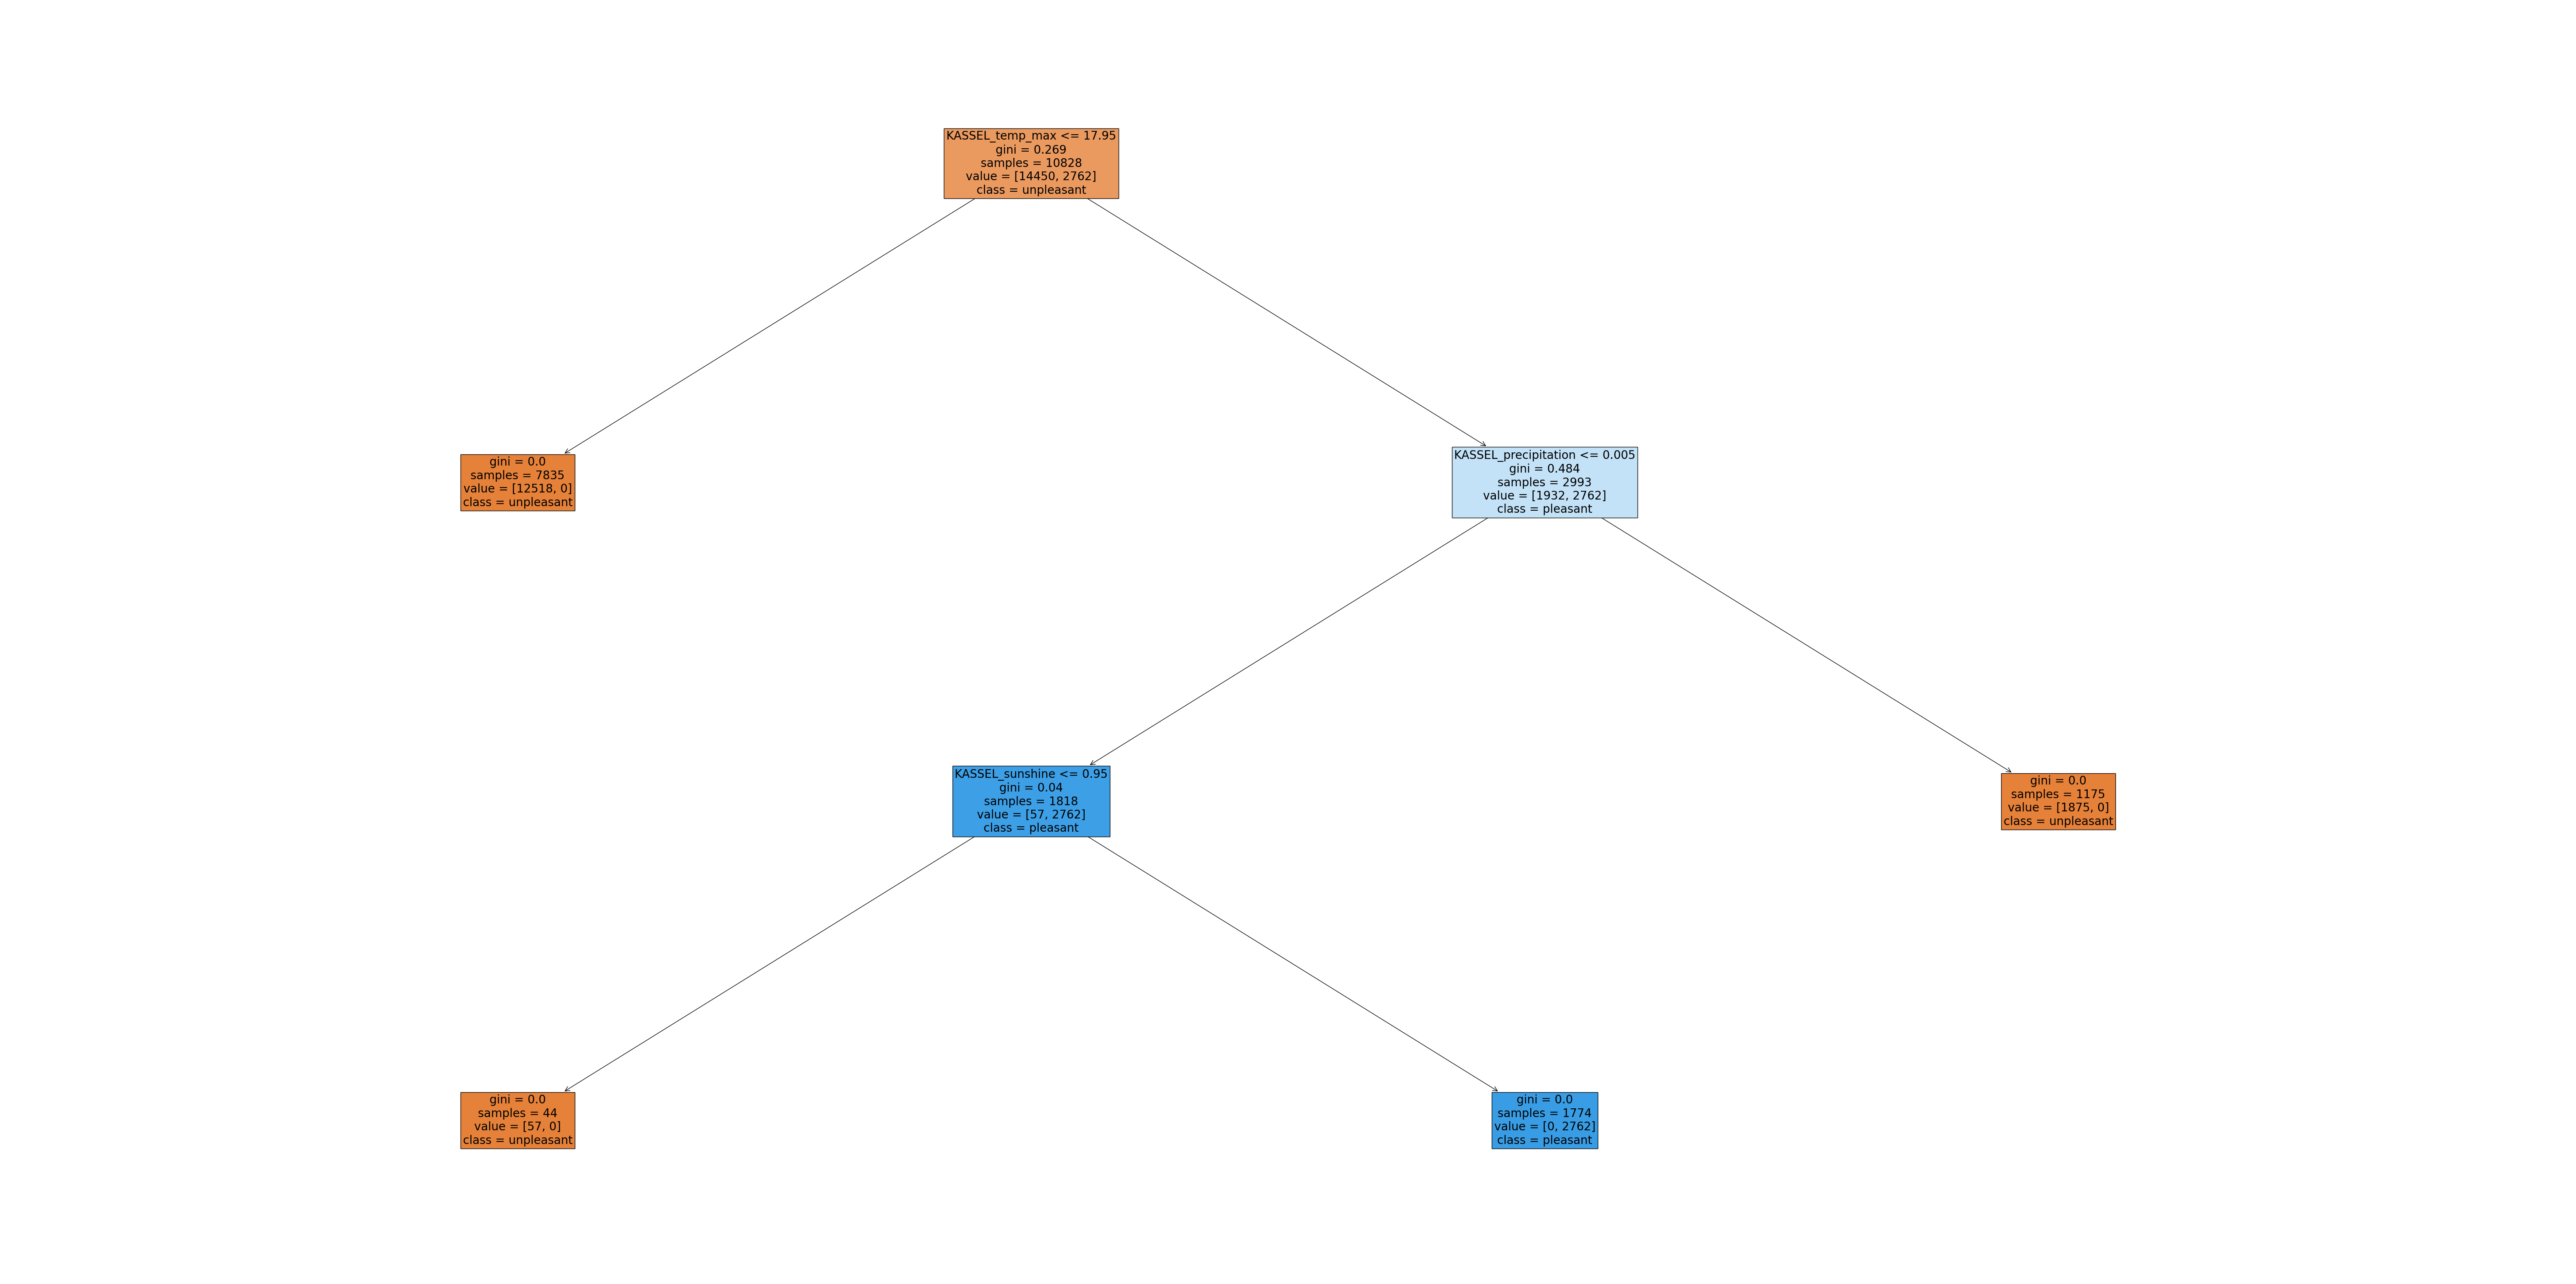

In [86]:
# Plotting the random forest

fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[6], fontsize = 20, feature_names = climatewins_Kassel.columns, class_names=['unpleasant', 'pleasant'], filled=True);

### 7. Feature Importances

In [91]:
# Retrieve feature importances from the trained model

feature_importances_3 = clf3.feature_importances_
print(clf3.feature_importances_.shape)
feature_importances_3

(9,)


array([2.60137871e-05, 4.22447328e-03, 4.02020284e-03, 2.36673508e-02,
       4.15869104e-01, 6.09987534e-02, 8.74287707e-02, 1.75517041e-04,
       4.03589815e-01])

In [93]:
# Create a list of weather features

weather_list = [feature.replace('KASSEL_', '') for feature in Kassel_list]
weather_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [95]:
important = pd.Series(feature_importances_3, index = weather_list)
important

cloud_cover         0.000026
humidity            0.004224
pressure            0.004020
global_radiation    0.023667
precipitation       0.415869
sunshine            0.060999
temp_mean           0.087429
temp_min            0.000176
temp_max            0.403590
dtype: float64

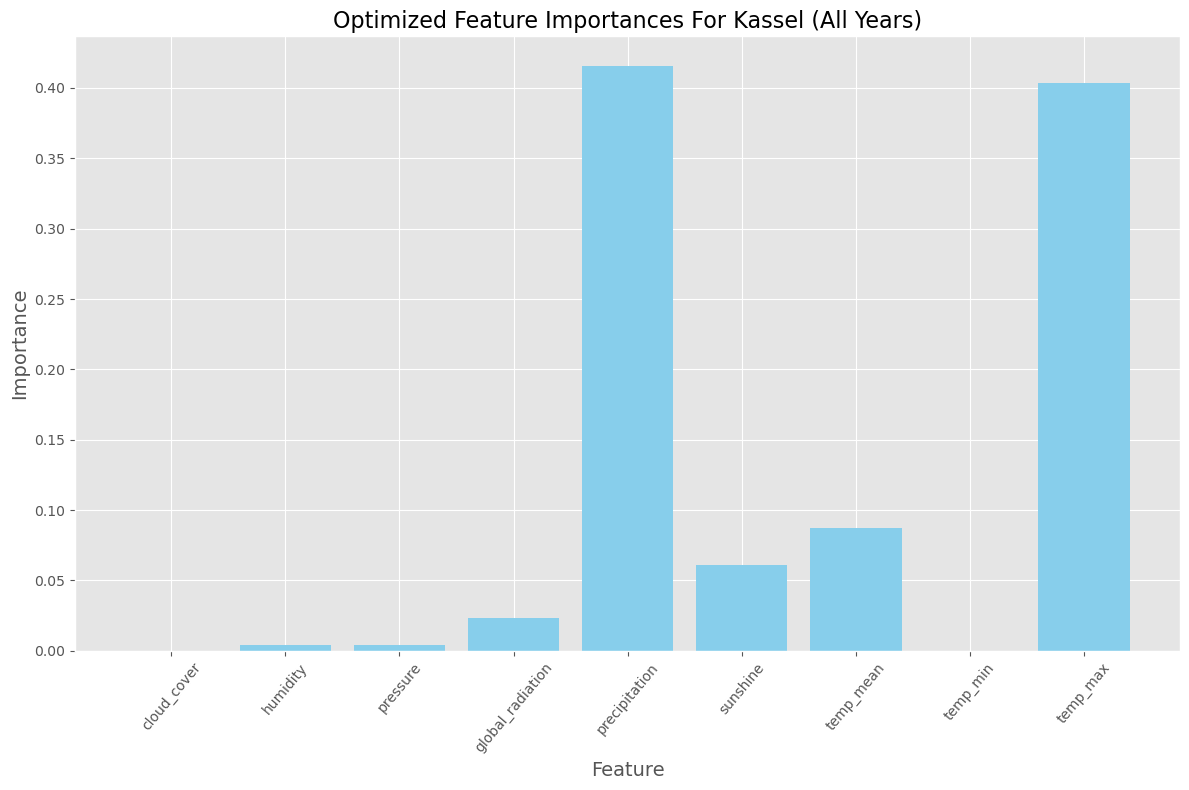

In [101]:
# Plotting the importances

%matplotlib inline

plt.style.use('ggplot')

x_values = list(range(len(feature_importances_3)))

plt_1 = plt.figure(figsize=(12, 8))
plt.bar(x_values, feature_importances_3, color='skyblue')
plt.xticks(x_values, weather_list,rotation=50, ha='center')
plt.xlabel('Feature', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Optimized Feature Importances For Kassel (All Years)', fontsize=16)
plt.tight_layout()
plt.show()